<a href="https://colab.research.google.com/github/anamacao/FAPESP-PIBIC-scrapping/blob/main/observacom.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import requests
from bs4 import BeautifulSoup
import pandas as pd
import sqlite3
import time
import re

import plotly.express as px
import plotly.io as pio
pio.renderers.default = "notebook_connected"

In [2]:
DATABASE_NAME = "internet_governance_news.db"

def create_database():
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    cursor.execute("""
        CREATE TABLE IF NOT EXISTS articles (
            id INTEGER PRIMARY KEY AUTOINCREMENT,
            title TEXT,
            date TEXT,
            author TEXT,
            url TEXT UNIQUE,
            source TEXT
        )
    """)
    conn.commit()
    conn.close()
    print("✅ Banco e tabela 'articles' prontos!")

create_database()

✅ Banco e tabela 'articles' prontos!


In [3]:
def insert_article(title, date, author, url, source):
    conn = sqlite3.connect(DATABASE_NAME)
    cursor = conn.cursor()
    try:
        cursor.execute("""
            INSERT INTO articles (title, date, author, url, source)
            VALUES (?, ?, ?, ?, ?)
        """, (title, date, author, url, source))
        conn.commit()
        return True
    except sqlite3.IntegrityError:
        return False
    finally:
        conn.close()

In [4]:
headers = {
    "User-Agent": "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/120.0.0.0 Safari/537.36"
}

noticias = []
total_pages = 186

for page in range(1, total_pages + 1):
    if page == 1:
        url = "https://www.observacom.org/seccion/actualidad/"
    else:
        url = f"https://www.observacom.org/seccion/actualidad/page/{page}/"

    print(f"📄 Coletando página {page}/{total_pages}: {url}")
    try:
        r = requests.get(url, headers=headers, timeout=10)
        r.raise_for_status()
    except requests.RequestException as e:
        print(f"❌ Erro ao acessar {url}: {e}")
        continue

    soup = BeautifulSoup(r.text, "html.parser")

    paineis = soup.find_all("article")
    if not paineis:
        paineis = [h2.parent for h2 in soup.find_all("h2") if h2.find("a")]

    if not paineis:
        print(f"⚠️ Nenhuma notícia encontrada na página {page}")
        continue

    print(f"   {len(paineis)} notícias encontradas")

    for item in paineis:
        titulo_tag = item.find(["h2", "h3"])
        if not titulo_tag:
            continue

        link_tag = titulo_tag.find("a")
        if not link_tag:
            continue

        link = link_tag.get("href")

        data_tag = item.find("time")

        author_tag = item.find(class_=re.compile("author"))
        author = author_tag.get_text(strip=True) if author_tag else "Observacom"

        data = {
            "title": titulo_tag.get_text(strip=True),
            "date": data_tag.get_text(strip=True) if data_tag else None,
            "author": author,
            "url": link,
            "source": "Observacom"
        }

        noticias.append(data)
        insert_article(**data)

    time.sleep(1) # pausa para não sobrecarregar o servidor

print(f"\n✅ Total coletado na Observacom nesta rodada: {len(noticias)} notícias")
df_observacom = pd.DataFrame(noticias)
if not df_observacom.empty:
    display(df_observacom.head())

📄 Coletando página 1/186: https://www.observacom.org/seccion/actualidad/
   12 notícias encontradas
📄 Coletando página 2/186: https://www.observacom.org/seccion/actualidad/page/2/
   12 notícias encontradas
📄 Coletando página 3/186: https://www.observacom.org/seccion/actualidad/page/3/
   12 notícias encontradas
📄 Coletando página 4/186: https://www.observacom.org/seccion/actualidad/page/4/
   12 notícias encontradas
📄 Coletando página 5/186: https://www.observacom.org/seccion/actualidad/page/5/
   12 notícias encontradas
📄 Coletando página 6/186: https://www.observacom.org/seccion/actualidad/page/6/
   12 notícias encontradas
📄 Coletando página 7/186: https://www.observacom.org/seccion/actualidad/page/7/
   12 notícias encontradas
📄 Coletando página 8/186: https://www.observacom.org/seccion/actualidad/page/8/
   12 notícias encontradas
📄 Coletando página 9/186: https://www.observacom.org/seccion/actualidad/page/9/
   12 notícias encontradas
📄 Coletando página 10/186: https://www.obser

,title,date,author,url,source
0,Prosigue reclamo de La Tercera en la Corte Sup...,"14 abril, 2026",Observacom,https://www.observacom.org/prosigue-reclamo-de...,Observacom
1,Conectados o atados a EEUU? Marco Rubio presio...,"13 abril, 2026",Nicolas Neves,https://www.observacom.org/conectados-o-atados...,Observacom
2,Dos fallos judiciales en EEUU atribuyen respon...,"27 marzo, 2026",Observacom,https://www.observacom.org/dos-fallos-judicial...,Observacom
3,La mitad de las noticias que recomienda Google...,"25 marzo, 2026",Observacom,https://www.observacom.org/la-mitad-de-las-not...,Observacom
4,Brasil actualiza su regulación de la inteligen...,"17 marzo, 2026",Observacom,https://www.observacom.org/brasil-actualiza-su...,Observacom


In [5]:
def load_articles():
    conn = sqlite3.connect(DATABASE_NAME)
    df = pd.read_sql("""
        SELECT * FROM articles
        ORDER BY date DESC
    """, conn)
    conn.close()
    return df

df_db = load_articles()
print(f"📦 Total no banco: {len(df_db)} registros")
display(df_db.head(20))

📦 Total no banco: 2178 registros


,id,title,date,author,url,source
0,728,Nueva sentencia de la Corte Europea determina ...,"9 septiembre, 2021",Observacom,https://www.observacom.org/nueva-sentencia-de-...,Observacom
1,1033,Gigantes tecnológicos centralizan el poder de ...,"9 septiembre, 2020",Observacom,https://www.observacom.org/gigantes-tecnologic...,Observacom
2,1289,Lobby de grupos evangélicos para reformar ley ...,"9 septiembre, 2019",Observacom,https://www.observacom.org/lobby-de-grupos-eva...,Observacom
3,1881,AMARC señala falta de voluntad política para r...,"9 septiembre, 2016",Observacom,https://www.observacom.org/amarc-senala-falta-...,Observacom
4,184,"Meta, Google y TikTok concentran el 70% del tr...","9 octubre, 2024",Observacom,https://www.observacom.org/meta-google-y-tikto...,Observacom
5,318,EEUU: Plataformas de servicios audiovisuales e...,"9 octubre, 2023",Observacom,https://www.observacom.org/eeuu-plataformas-de...,Observacom
6,999,Regulador audiovisual de Cataluña solicitó a T...,"9 octubre, 2020",Observacom,https://www.observacom.org/regulador-audiovisu...,Observacom
7,1000,El proyecto oficialista de Ley de Medios promu...,"9 octubre, 2020",Observacom,https://www.observacom.org/el-proyecto-oficial...,Observacom
8,1267,República Dominicana comenzará a cobrar impues...,"9 octubre, 2019",Observacom,https://www.observacom.org/republica-dominican...,Observacom
9,1470,Sociedad Civil chilena solicita participar en ...,"9 octubre, 2018",Observacom,https://www.observacom.org/sociedad-civil-chil...,Observacom


In [9]:
def plot_charts(df):
    if df.empty:
        print("❌ Sem dados para plotar")
        return

    # Usando o renderizador nativo do Colab
    import plotly.io as pio
    pio.renderers.default = "colab"

    # 1. Top 15 Notícias Recentes
    top15 = df.head(15).copy()
    fig1 = px.bar(
        top15,
        y="title",
        x=top15.index,
        orientation="h",
        title="Top 15 Notícias Recentes",
        labels={"title": "Título", "index": "Posição"}
    )
    fig1.update_layout(yaxis={'categoryorder':'total ascending'}, height=600)
    fig1.show()

    # 2. Distribuição por Fonte
    source_count = df["source"].value_counts().reset_index()
    source_count.columns = ["source", "count"]
    fig2 = px.pie(
        source_count,
        names="source",
        values="count",
        title="Distribuição por Fonte"
    )
    fig2.show()

    # 3. Palavras mais frequentes
    stop_words = {'para', 'com', 'uma', 'pelo', 'pela', 'mais', 'sobre', 'entre', 'como', 'sua', 'seu', 'está', 'pode', 'estão'}
    text = " ".join(df["title"].astype(str)).lower()
    words = re.findall(r'\b\w{4,}\b', text)
    filtered_words = [w for w in words if w not in stop_words]

    word_freq = (
        pd.Series(filtered_words)
        .value_counts()
        .head(25)
        .reset_index()
    )
    word_freq.columns = ["palavra", "freq"]

    fig3 = px.treemap(
        word_freq,
        path=["palavra"],
        values="freq",
        title="Palavras mais frequentes nos títulos (mín. 4 letras)"
    )
    fig3.show()

plot_charts(df_db)

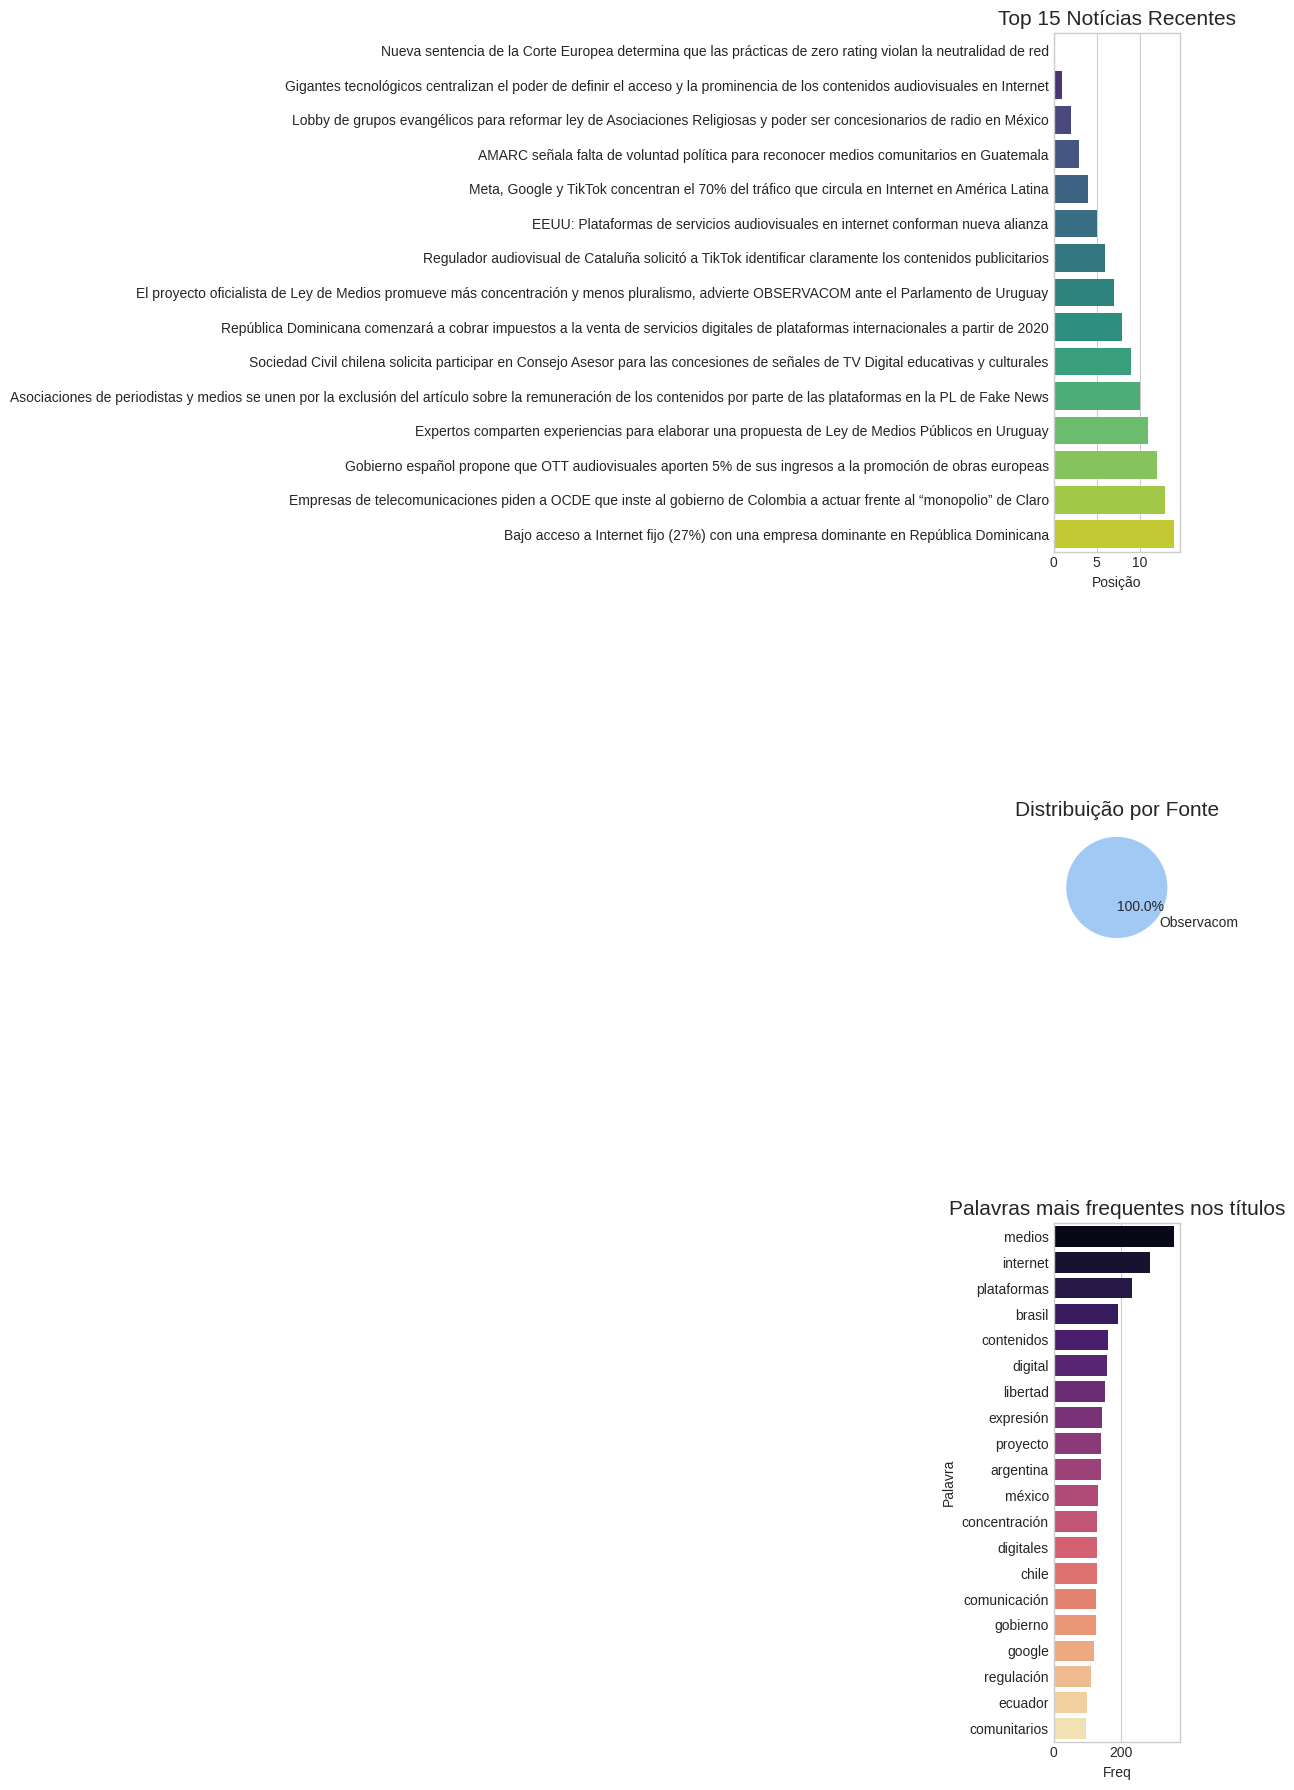

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

def plot_static_charts(df):
    if df.empty:
        print("❌ Sem dados para plotar")
        return

    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axes = plt.subplots(3, 1, figsize=(12, 18))

    # 1. Top 15 Notícias
    top15 = df.head(15)
    sns.barplot(data=top15, x=top15.index, y="title", ax=axes[0], hue="title", palette="viridis", legend=False)
    axes[0].set_title("Top 15 Notícias Recentes", fontsize=15)
    axes[0].set_xlabel("Posição")
    axes[0].set_ylabel("")

    # 2. Distribuição por Fonte
    source_counts = df["source"].value_counts()
    axes[1].pie(source_counts, labels=source_counts.index, autopct='%1.1f%%', startangle=140, colors=sns.color_palette("pastel"))
    axes[1].set_title("Distribuição por Fonte", fontsize=15)

    # 3. Palavras Frequentes
    stop_words = {'para', 'com', 'uma', 'pelo', 'pela', 'mais', 'sobre', 'entre', 'como', 'sua', 'seu', 'está', 'pode', 'estão'}
    text = " ".join(df["title"].astype(str)).lower()
    words = [w for w in re.findall(r'\b\w{4,}\b', text) if w not in stop_words]
    word_counts = Counter(words).most_common(20)
    word_df = pd.DataFrame(word_counts, columns=['Palavra', 'Freq'])

    sns.barplot(data=word_df, x='Freq', y='Palavra', ax=axes[2], hue='Palavra', palette="magma", legend=False)
    axes[2].set_title("Palavras mais frequentes nos títulos", fontsize=15)

    plt.tight_layout()
    plt.show()

plot_static_charts(df_db)

In [12]:
def analyze_trends(df):
    if df.empty:
        print("❌ Sem dados para analisar")
        return

    # Dicionário para tradução de meses em espanhol para inglês (Pandas format)
    meses_es = {
        'enero': 'January', 'febrero': 'February', 'marzo': 'March', 'abril': 'April',
        'mayo': 'May', 'junio': 'June', 'julio': 'July', 'agosto': 'August',
        'septiembre': 'September', 'octubre': 'October', 'noviembre': 'November', 'diciembre': 'December'
    }

    def clean_date(date_str):
        if not date_str or not isinstance(date_str, str):
            return None
        d = date_str.lower()
        for es, en in meses_es.items():
            d = d.replace(es, en)
        try:
            return pd.to_datetime(d, errors='coerce')
        except:
            return None

    df_trends = df.copy()
    df_trends['date_clean'] = df_trends['date'].apply(clean_date)
    df_trends = df_trends.dropna(subset=['date_clean'])
    df_trends['year'] = df_trends['date_clean'].dt.year

    # Filtrar stop words
    stop_words = {'para', 'com', 'uma', 'pelo', 'pela', 'mais', 'sobre', 'entre', 'como', 'sua', 'seu', 'está', 'pode', 'estão', 'desde', 'este', 'esta'}

    yearly_data = []

    # Analisar top 5 palavras por ano (últimos 5 anos com dados)
    recent_years = sorted(df_trends['year'].unique())[-6:]

    for year in recent_years:
        titles = " ".join(df_trends[df_trends['year'] == year]['title'].astype(str)).lower()
        words = [w for w in re.findall(r'\b\w{5,}\b', titles) if w not in stop_words]
        top_words = Counter(words).most_common(5)
        for word, count in top_words:
            yearly_data.append({"Ano": year, "Palavra": word, "Frequência": count})

    df_plot = pd.DataFrame(yearly_data)

    fig = px.bar(
        df_plot,
        x="Ano",
        y="Frequência",
        color="Palavra",
        title="Tendência de Tópicos: Principais Palavras por Ano",
        barmode="group"
    )
    fig.update_layout(xaxis_type='category')
    fig.show()

analyze_trends(df_db)

In [16]:
def analyze_total_on_trends_with_chart(df):
    if df.empty:
        print("❌ Sem dados para analisar")
        return

    # 1. Identificar os tópicos em alta
    stop_words = {'para', 'com', 'uma', 'pelo', 'pela', 'mais', 'sobre', 'entre', 'como', 'sua', 'seu', 'está', 'pode', 'estão', 'desde', 'este', 'esta'}
    text = " ".join(df["title"].astype(str)).lower()
    words = [w for w in re.findall(r'\b\w{5,}\b', text) if w not in stop_words]
    word_counts = Counter(words).most_common(10)
    top_trends = [word for word, count in word_counts]

    # 2. Filtrar notícias que contenham esses tópicos
    pattern = '|'.join(top_trends)
    df_filtered = df[df['title'].str.contains(pattern, case=False, na=False)]
    total_artigos = len(df_filtered)

    print(f"🔍 Tópicos em alta: {', '.join(top_trends)}")
    print(f"📊 Total de artigos nesses temas: {total_artigos}\n")

    # 3. Visualização dos termos de tendência
    df_plot = pd.DataFrame(word_counts, columns=['Termo', 'Frequência'])

    import plotly.express as px
    fig = px.bar(
        df_plot,
        x='Frequência',
        y='Termo',
        orientation='h',
        title=f"Top Termos de Tendência (Total de Artigos: {total_artigos})",
        color='Frequência',
        color_continuous_scale='Blues'
    )
    fig.update_layout(yaxis={'categoryorder':'total ascending'})
    fig.show()

analyze_total_on_trends_with_chart(df_db)

🔍 Tópicos em alta: medios, internet, plataformas, brasil, contenidos, digital, libertad, expresión, proyecto, argentina
📊 Total de artigos nesses temas: 1329

